# Análisis de Calidad de Datos - Dataset EAC DANE

Este notebook realiza un análisis de la calidad de datos del dataset de la Encuesta Anual de Comercio (EAC) del DANE. El objetivo es identificar valores que puedan afectar las diferentes capas de calidad de los datos empresariales.

## 1. Configuración Inicial y Carga de Librerías

En esta sección configuramos el entorno de trabajo importando las librerías necesarias y el módulo validador personalizado que contiene las reglas de validación de datos empresariales.

In [56]:
import sys
import os
import pandas as pd
import numpy as np
sys.path.append(os.path.abspath(".."))

from src.validator import validador, rules, produccion, expenses_op, general_G

## 2. Carga del Dataset Principal

Cargamos el dataset de la Encuesta Anual de Comercio (EAC) desde el archivo CSV. Este dataset contiene información financiera y operacional de empresas colombianas del sector comercio.

In [57]:
df = pd.read_csv("../dataFrames/data.csv")
df.head()

,V1,CORRELA_16,CORRE_9,IDOJ1,IDAIO,CIMREP,BRUTA,CONSUI,GAS,EMPAQUE,...,INVINI,INVFIN,ROTACION,INVPRO,CTO,CTOINS,VENTASNOP,GASTOS,GASTOSNOP,GASTOPNOP
0,987664,4711-472,471-472,11.0,1986.0,0,603028,"112214,5",0,0,...,2409090,2499584,4837343,2454337,4837343,4837343,0,4980000,1110,5145586
1,987666,462,462-463,14.0,1996.0,0,1083695,77336,780,2970,...,3193,476400,4820346,"239796,5",4820346,4820346,0,4928292,1255,5288743
2,987667,4771-4751,476 - 477,4.0,1991.0,0,190661,26863,0,0,...,431759,422759,515488,427259,515488,515488,0,548094,16772,701070
3,987668,466,466-469,14.0,1986.0,0,2459238,"1262835,5",0,0,...,1963161,2694017,13114471,2328589,13114471,13114471,0,14487926,62938,14895893
4,987669,473,473,5.0,2004.0,0,1688361,"218895,5",0,0,...,141377,172460,7766200,"156918,5",7766200,7766200,0,8044113,57255,8847340


## 3. Selección de Columnas de Análisis

Filtramos el dataset para incluir únicamente las columnas relevantes para el análisis de calidad:

In [58]:
df = df[produccion+expenses_op+general_G]

df.info()
# transformar IDOJ1,IDAIO  a un entero

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9984 entries, 0 to 9983
Data columns (total 25 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   VENTA        9984 non-null   object
 1   BRUTA        9984 non-null   object
 2   CONSUI       9984 non-null   object
 3   AGREGA       9984 non-null   object
 4   CTO          9983 non-null   object
 5   GAS          9984 non-null   object
 6   EMPAQUE      9984 non-null   object
 7   HONORA       9984 non-null   object
 8   COMISION     9984 non-null   object
 9   ARRIENDO     9984 non-null   object
 10  SEGURO       9984 non-null   object
 11  ASEO         9984 non-null   object
 12  ENERGIA      9984 non-null   object
 13  COMUNICA     9984 non-null   object
 14  PUBLICO      9984 non-null   object
 15  FLETES       9984 non-null   object
 16  PUBLICI      9984 non-null   object
 17  ADECUA       9984 non-null   object
 18  REGALA       9984 non-null   object
 19  OUTSOURCING  9984 non-null 

## 4. Limpieza y Transformación de Datos

In [59]:
def parse_float(val):
    try:
        val = str(val).replace('.', '').replace(',', '.')
        return float(val)
    except ValueError:
        return np.nan

for col in df.columns:
    df[col] = df[col].apply(parse_float)

## 5. Aplicación del Validador de Calidad

Ejecutamos el validador personalizado que aplica un conjunto de reglas de negocio para evaluar la consistencia y calidad de los datos empresariales. Las reglas incluyen:
- Validaciones de coherencia contable
- Verificación de rangos lógicos
- Consistencia entre variables relacionadas

In [60]:
# evaluacion de el dataset

resultado = validador(df, rules)

print(resultado)

                   regla  cantidad_invalidos  porcentaje_invalidos
0                  nulos                   1                  0.01
1       venta_produccion                   0                  0.00
2     produccion_consumo                  96                  0.96
3         valor_agregado                  42                  0.42
4                 costos                   0                  0.00
5             eficiencia                  15                  0.15
6    margen_val_agregado                  96                  0.96
7    consistencia_gastos                   0                  0.00
8      proporcion_ventas                 195                  1.95
9   peso_relativo_gastos                   9                  0.09
10    rentabilidad_bruta                  15                  0.15


## 6. Visualización de Resultados de Calidad

Generamos un gráfico de barras horizontales que muestra el porcentaje de registros inválidos por cada regla de validación. Esta visualización permite:
- Identificar rápidamente las reglas con mayor número de violaciones
- Priorizar las áreas que requieren mayor atención en la limpieza de datos
- Evaluar la calidad general del dataset

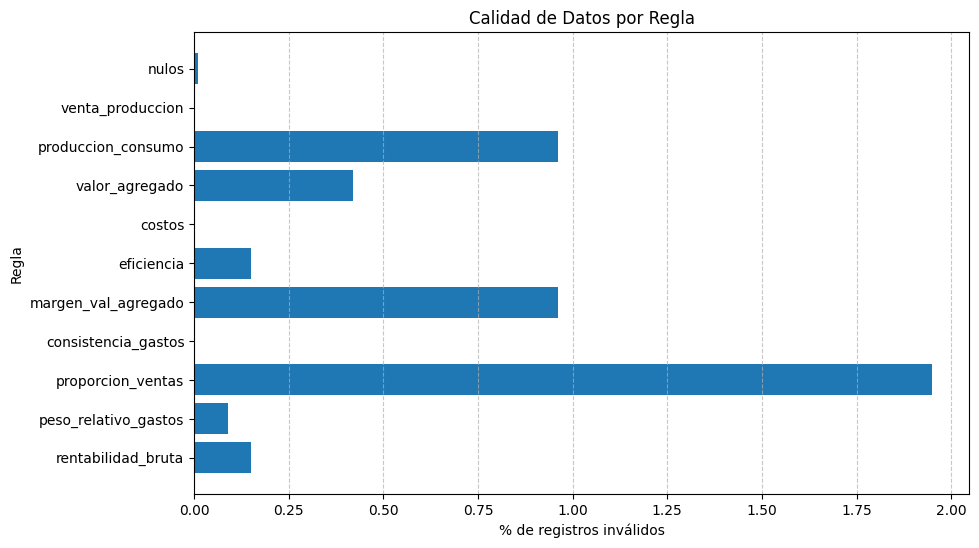

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(resultado['regla'], resultado['porcentaje_invalidos'])
plt.xlabel('% de registros inválidos')
plt.ylabel('Regla')
plt.title('Calidad de Datos por Regla')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


## 7. Extracción y Exportación de Registros Inválidos

In [62]:
invalid_rows = pd.concat([
    funcion(df)['filas']
    for funcion in rules.values()
]).drop_duplicates()

invalid_rows.to_csv("../dataFrames/invalidData.csv")

## 8. Simulación de Datos con Errores Controlados

En esta sección realizamos experimentos con datos sintéticos para evaluar el comportamiento del validador bajo diferentes escenarios. 

### 8.1 Carga del Simulador de Datos

In [63]:
from src.simulator import data_simulator

### 8.2 Generación de Dataset con Alta Tasa de Errores

In [64]:
df_error_simulated = data_simulator(invalid_rows, 5000, 0.05)

df_error_simulated.to_csv("../dataFrames/simulated_invalid_Data.csv")

result_invalid_simulated = validador(df_error_simulated, rules)

print(result_invalid_simulated)

                   regla  cantidad_invalidos  porcentaje_invalidos
0                  nulos                  23                  0.46
1       venta_produccion                   0                  0.00
2     produccion_consumo                2208                 44.16
3         valor_agregado                2539                 50.78
4                 costos                2326                 46.52
5             eficiencia                 345                  6.90
6    margen_val_agregado                2213                 44.26
7    consistencia_gastos                   0                  0.00
8      proporcion_ventas                4408                 88.16
9   peso_relativo_gastos                 201                  4.02
10    rentabilidad_bruta                 345                  6.90


### 8.3 Visualización de Resultados - Dataset con Errores Simulados

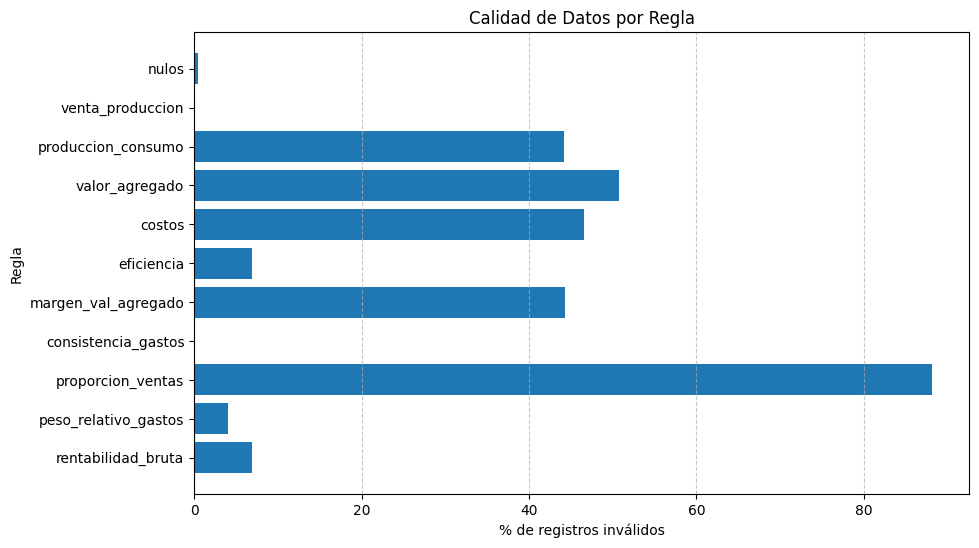

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(result_invalid_simulated['regla'], result_invalid_simulated['porcentaje_invalidos'])
plt.xlabel('% de registros inválidos')
plt.ylabel('Regla')
plt.title('Calidad de Datos por Regla')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


## 9. Validación con Dataset Sintético de Alta Calidad

### 9.1 Generación de Dataset de Alta Calidad

In [66]:
df_simulated = data_simulator(df,10000,0.001)

df_simulated.to_csv("../dataFrames/simulated_Data.csv")

result_simulated = validador(df_simulated, rules)

print(result_simulated)

                   regla  cantidad_invalidos  porcentaje_invalidos
0                  nulos                   1                  0.01
1       venta_produccion                 140                  1.40
2     produccion_consumo                 247                  2.47
3         valor_agregado                5095                 50.95
4                 costos                4634                 46.34
5             eficiencia                 168                  1.68
6    margen_val_agregado                 348                  3.48
7    consistencia_gastos                 137                  1.37
8      proporcion_ventas                 346                  3.46
9   peso_relativo_gastos                 299                  2.99
10    rentabilidad_bruta                 168                  1.68


### 9.2 Visualización Final - Comparación de Calidad

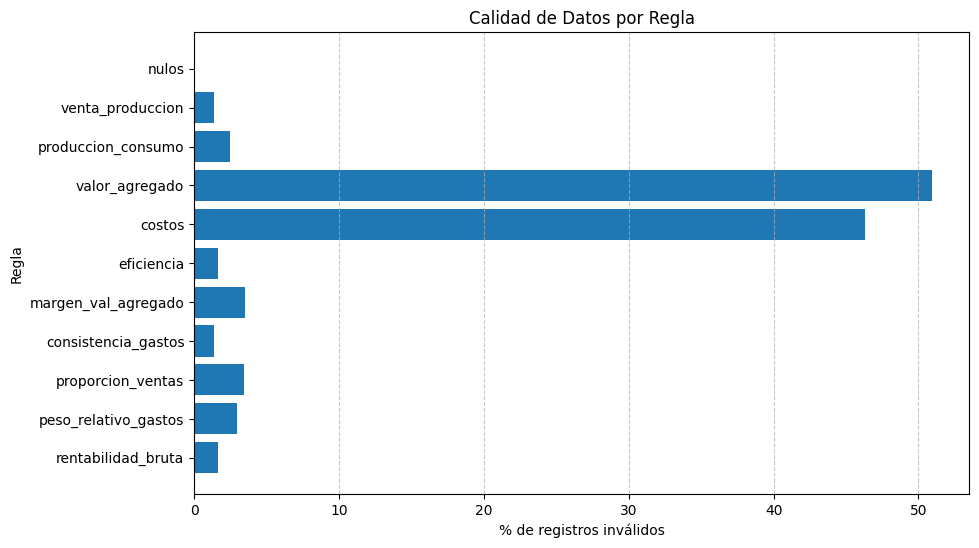

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(result_simulated['regla'], result_simulated['porcentaje_invalidos'])
plt.xlabel('% de registros inválidos')
plt.ylabel('Regla')
plt.title('Calidad de Datos por Regla')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()
